# ASV Averages by Niche



Loads data generated with `sig_avg_STA_ASVs.py`. 

Jones-Kellett et al. figs in this script: Fig. 6a-c



NOTES

Cleaning up this code for manuscript revision by moving out of messier working script (`pcc_dist_by_physical_state_v2.ipynb`). 

---

LJK 

Date created: 02/27/26

Last edited: 03/03/26

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from config import * # directory file paths

In [2]:
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

### Load Datasets

In [3]:
metadata_df = pd.read_csv(data_dir + 'AVISO_metadata_15km_near_eddy_w_coh_time.csv',index_col=0)
metadata_df

,date,time_UTC,latitude,longitude,in_anti,near_anti,in_cyc,near_cyc,eddy_indicator,mean_coh
sample_id,,,,,,,,,,
16,20211120,10:54,29.0000,236.5574,0,0,0,0,O,32.666667
17,20211120,12:44,28.7390,236.1088,0,0,0,0,O,43.666667
18,20211120,14:43,28.5030,235.7140,0,0,0,0,O,40.166667
19,20211121,02:03,28.2847,235.3517,0,0,0,0,O,97.083333
20,20211121,04:04,28.0397,234.9534,0,0,0,0,O,63.416667
21,20211121,06:05,27.8012,234.5413,0,0,849094,0,Y,50.416667
22,20211121,08:00,27.5684,234.1578,0,0,0,849094,N,49.000000
23,20211121,09:53,27.3373,233.7767,0,0,0,0,O,45.583333
24,20211121,11:53,27.0992,233.3740,0,0,0,0,O,12.833333


In [4]:
euk_ASV_STA = pd.read_csv(highcov_dir + 'euk_phyto_ASV_spatiotemporal_anoms_v3.csv',index_col=0)
euk_ASV_STA.head()

,2f52bfb075d038a1b72a4dd9d53a01e8,a90268a55b92cdf24a7be460a63b6f60,3a9e3efa6d0f0df69668b602c9bac618,c11382dbe93c5cf9e98818644c10014b,34178fed607a631f7a37c6b2b70ca571,33710095af4d10c80e36a6e6cb82bae3,fec340993a739ee01f6eb267e367ea53,5d9c8af2f6a20888621ccca9ee9d21c8,75549981911a6cb5fe1cdf04b9f25a59,aae534727c3716a3160ae2d66d4b01d7,...,8f71038498fff0c33514c4ddea1e51f5,c77b7f8f9c686383ea2b8bb57b1f1bed,dac491346912fa89ffff65876682991e,be72ca18d889c0b3c73e6ad74f34d10e,cbab111de8d072e62e59e05b16d5765b,82aba3a2486a226f16d0c8e5cf529fdc,92626f2f1d450a4b79639dc3cd43b94e,3bdb1b23136e9e81d05d89d726e4acb8,d39588a7902cf12f3af8b02b3fff16a8,f0c7ae3f06a1bed27c76d1af2fdaa4de
sample_id,,,,,,,,,,,,,,,,,,,,,
16,49.124039,-20.826416,-131.490700,52.128020,77.056998,0.195367,-11.119705,-23.139071,-40.757154,27.280575,...,0.403846,-3.550074,-4.575918,-5.382022,-0.917566,50.155132,-8.052229,0.353012,0.090839,-0.136512
17,-66.273342,-80.655295,-11.634046,-74.369050,160.373505,0.209551,19.412786,-1.431117,-19.729655,8.675752,...,0.552391,72.706139,26.489422,-12.570320,0.264977,-3.903811,-4.167615,-7.252143,0.144798,-0.043383
18,138.263023,29.535534,139.397017,44.493059,272.358545,0.263362,60.687736,118.751871,22.256073,9.500296,...,-0.143068,-44.329340,-6.694910,33.066476,-1.421847,6.232688,30.275746,-7.956462,0.168424,0.272434
19,-170.025606,-78.640806,-175.594066,19.853648,-157.425545,0.382135,-142.492658,-153.946920,17.219530,-55.045782,...,0.249354,-4.509266,-2.099505,-0.673725,0.259586,-0.529668,17.781629,12.444914,0.161594,-1.224568
20,-33.714688,53.598604,5.962880,-91.997311,-102.809827,0.163967,-14.587965,-285.021230,-71.422668,0.627816,...,-0.869597,-23.224351,-3.274795,-7.497930,0.376256,-9.845695,1.364314,-0.244684,-0.292077,-0.688781


In [5]:
sig_ASV_STA = pd.read_csv(highcov_dir + 'sig_avg_STA_ASVs_by_niche.csv',index_col=0)
sig_ASV_STA

,Eddy,Outside Mixed,Outside Coherent
2f52bfb075d038a1b72a4dd9d53a01e8,0,1,1
a90268a55b92cdf24a7be460a63b6f60,1,1,1
3a9e3efa6d0f0df69668b602c9bac618,0,1,1
c11382dbe93c5cf9e98818644c10014b,0,1,1
34178fed607a631f7a37c6b2b70ca571,1,1,1
...,...,...,...
82aba3a2486a226f16d0c8e5cf529fdc,1,1,0
92626f2f1d450a4b79639dc3cd43b94e,0,0,0
3bdb1b23136e9e81d05d89d726e4acb8,0,0,0
d39588a7902cf12f3af8b02b3fff16a8,0,0,1


### Plot Ranked STAs

In [6]:
eddy_samples = list(metadata_df[(metadata_df.eddy_indicator != 'O')].index)
outside_mixed_samples = list(metadata_df[(metadata_df.eddy_indicator == 'O') & (metadata_df.mean_coh < 90)].index)
outside_coh_samples = list(metadata_df[(metadata_df.eddy_indicator == 'O') & (metadata_df.mean_coh >= 90)].index)

In [7]:
sig_pos_color = 'firebrick'
non_sig_pos_color = 'lightcoral'
sig_neg_color = 'mediumblue'
non_sig_neg_color = 'cornflowerblue'

In [8]:
def get_rank_STA(sample_set,sig_ASV_STA_col_name):
    
    # Rank ASVs by their mean STA within the sample set 
    heights_df = (euk_ASV_STA.loc[sample_set].mean(axis=0)).sort_values(ascending=True) # average STA, ranked
    heights = heights_df.values
    ASVs = heights_df.index # sorted by value
    
    # log modulus transformation for visual purposes
    log_heights = np.concatenate((-1*np.log(-1*heights[heights<0] + 1),np.log(heights[heights>=0] + 1)))
    
    sig_pos_ASVs,sig_neg_ASVs = [],[]
    colors = []
    for ASV in ASVs:
        ASV_sig = sig_ASV_STA.loc[ASV][sig_ASV_STA_col_name]
        if ASV_sig == 1: # significant
            if heights_df.loc[ASV] > 0:
                colors.append(sig_pos_color)
                sig_pos_ASVs.append(ASV)
            elif heights_df.loc[ASV] < 0:
                colors.append(sig_neg_color)
                sig_neg_ASVs.append(ASV)
            
        else:
            if heights_df.loc[ASV] > 0:
                colors.append(non_sig_pos_color)
            elif heights_df.loc[ASV] < 0:
                colors.append(non_sig_neg_color)
    
    return ASVs, colors, heights, log_heights, sig_pos_ASVs, sig_neg_ASVs

In [9]:
def sign_switch_index(ordered_list):
    """
    Find where in ordered list the sign changes 
    """
    pair1, pair2 = ordered_list[:-1], ordered_list[1:] # used compare adjacent values in the original list
    
    ind = 0 # counter to return index of sign switch
    for (p1,p2) in list(zip(pair1,pair2)):
        if p1*p2 < 0: # indicates sign switch 
            break 
        else:
            ind += 1
            
    return ind

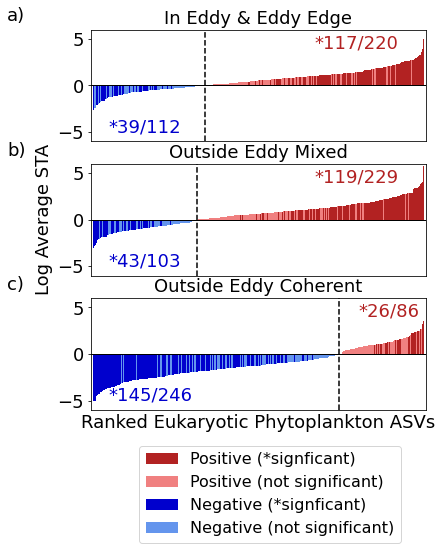

In [25]:
fig,ax = plt.subplots(3,1,figsize=(6,7))

## EDDY STA ##
label_height = 2
eddy_ASVs, eddy_colors, eddy_heights, eddy_log_heights, eddy_sig_pos_ASVs, eddy_sig_neg_ASVs = get_rank_STA(eddy_samples,'Eddy')
ax[0].bar(eddy_ASVs,eddy_log_heights,color=eddy_colors,width=1)

# Fraction of significant positive 
ax[0].text(len(eddy_ASVs)/1.5,4,'*%s/%s'%(eddy_colors.count('firebrick'),
                     eddy_colors.count('firebrick')+eddy_colors.count('lightcoral')),c='firebrick')

# Fraction of significant negative 
ax[0].text(15,-5,'*%s/%s'%(eddy_colors.count('mediumblue'),
                     eddy_colors.count('mediumblue')+eddy_colors.count('cornflowerblue')),c='mediumblue')

# Line demarking transition from negative to positive
ax[0].axvline(sign_switch_index(eddy_heights)+1,c='k',linestyle='--')
ax[0].set_title('In Eddy & Eddy Edge')

## OUTSIDE MIXED ##
mixed_ASVs, mixed_colors, mixed_heights, mixed_log_heights, mixed_sig_pos_ASVs, mixed_sig_neg_ASVs = get_rank_STA(outside_mixed_samples,'Outside Mixed')
ax[1].bar(mixed_ASVs,mixed_log_heights,color=mixed_colors,width=1)
ax[1].text(len(mixed_ASVs)/1.5,4,'*%s/%s'%(mixed_colors.count('firebrick'),
                     mixed_colors.count('firebrick')+mixed_colors.count('lightcoral')),c='firebrick')
ax[1].text(15,-5,'*%s/%s'%(mixed_colors.count('mediumblue'),
                     mixed_colors.count('mediumblue')+mixed_colors.count('cornflowerblue')),c='mediumblue')
ax[1].axvline(sign_switch_index(mixed_heights)+1,c='k',linestyle='--')
ax[1].set_title('Outside Eddy Mixed')

## OUTSIDE COH ##
coh_ASVs, coh_colors, coh_heights, coh_log_heights, coh_sig_pos_ASVs, coh_sig_neg_ASVs = get_rank_STA(outside_coh_samples,'Outside Coherent')
ax[2].bar(coh_ASVs,coh_log_heights,color=coh_colors,width=1)
ax[2].text(len(coh_ASVs)/1.25,4,'*%s/%s'%(coh_colors.count('firebrick'),
                     coh_colors.count('firebrick')+coh_colors.count('lightcoral')),c='firebrick')
ax[2].text(15,-5,'*%s/%s'%(coh_colors.count('mediumblue'),
                     coh_colors.count('mediumblue')+coh_colors.count('cornflowerblue')),c='mediumblue')
ax[2].axvline(sign_switch_index(coh_heights)+1,c='k',linestyle='--')
ax[2].set_title('Outside Eddy Coherent')
ax[2].set_xlabel('Ranked Eukaryotic Phytoplankton ASVs')

# Define your color → label mapping
color_labels = {'firebrick': 'Positive (*signficant)',
                'lightcoral': 'Positive (not significant)',
                'mediumblue': 'Negative (*signficant)',
                'cornflowerblue': 'Negative (not significant)'}

# Create legend handles (one per unique color)
handles = [Patch(facecolor=color, edgecolor='none', label=label)
           for color, label in color_labels.items()]

# Add legend ONLY to axis 1
ax[2].legend(handles=handles, bbox_to_anchor=(0.95,-0.25), fontsize=16)

for a in ax:
    a.set_xticks([])
    a.set_xticklabels([])
    a.axhline(0,c='k',linewidth=1)
    a.set_xlim(-3,len(eddy_ASVs)+1)
    a.set_ylim(-6,6)
    
ax[1].set_ylabel('Log Average STA')

panel_labels = ['a)','b)','c)']
for count in range(len(panel_labels)):
    ax[count].text(-0.25, 1.2, panel_labels[count],transform=ax[count].transAxes,va='top',ha='left')
    

plt.savefig(euk_paper_dir + 'figs/prelim/euk_ASV_rank_abundance_and_STA_v3.pdf',dpi=350,bbox_inches='tight',format='pdf')

In [11]:
def calculate_venn_values(list_a, list_b, list_c):
    
    # Convert lists to sets to use set operations
    A = set(list_a)
    B = set(list_b)
    C = set(list_c)

    # Counts for each possible comparison
    only_A = len(A - B - C)
    only_B = len(B - A - C)
    only_C = len(C - A - B)
    A_and_B_only = len((A & B) - C)
    A_and_C_only = len((A & C) - B)
    B_and_C_only = len((B & C) - A)
    A_and_B_and_C = len(A & B & C)

    # Return dict of counts
    return {'only_A': only_A,
            'only_B': only_B,
            'only_C': only_C,
            'A_and_B_only': A_and_B_only,
            'A_and_C_only': A_and_C_only,
            'B_and_C_only': B_and_C_only,
            'A_and_B_and_C': A_and_B_and_C}

Comparison of ASVs with significant averages

In [12]:
calculate_venn_values(eddy_sig_pos_ASVs,mixed_sig_pos_ASVs,coh_sig_pos_ASVs)

{'only_A': 89,
 'only_B': 90,
 'only_C': 17,
 'A_and_B_only': 24,
 'A_and_C_only': 4,
 'B_and_C_only': 5,
 'A_and_B_and_C': 0}

In [13]:
calculate_venn_values(eddy_sig_neg_ASVs,mixed_sig_neg_ASVs,coh_sig_neg_ASVs)

{'only_A': 30,
 'only_B': 34,
 'only_C': 127,
 'A_and_B_only': 0,
 'A_and_C_only': 9,
 'B_and_C_only': 9,
 'A_and_B_and_C': 0}

Comparison of all positive 

In [14]:
calculate_venn_values([ASV for (ASV,height) in zip(eddy_ASVs,eddy_heights) if height>0],
                      [ASV for (ASV,height) in zip(mixed_ASVs,mixed_heights) if height>0],
                      [ASV for (ASV,height) in zip(coh_ASVs,coh_heights) if height>0])

{'only_A': 56,
 'only_B': 69,
 'only_C': 9,
 'A_and_B_only': 119,
 'A_and_C_only': 36,
 'B_and_C_only': 32,
 'A_and_B_and_C': 9}

### Table of Results

In [15]:
sig_ASV_STA_table = sig_ASV_STA.copy()
sig_ASV_STA_table = sig_ASV_STA_table.rename(columns={'Eddy':'Eddy Significance','Outside Mixed':'Outside Mixed Significance','Outside Coherent':'Outside Coherent Significance'})
sig_ASV_STA_table

,Eddy Significance,Outside Mixed Significance,Outside Coherent Significance
2f52bfb075d038a1b72a4dd9d53a01e8,0,1,1
a90268a55b92cdf24a7be460a63b6f60,1,1,1
3a9e3efa6d0f0df69668b602c9bac618,0,1,1
c11382dbe93c5cf9e98818644c10014b,0,1,1
34178fed607a631f7a37c6b2b70ca571,1,1,1
...,...,...,...
82aba3a2486a226f16d0c8e5cf529fdc,1,1,0
92626f2f1d450a4b79639dc3cd43b94e,0,0,0
3bdb1b23136e9e81d05d89d726e4acb8,0,0,0
d39588a7902cf12f3af8b02b3fff16a8,0,0,1


In [16]:
sig_ASV_STA_table.insert(loc=0, column='Eddy Mean STA',value=np.nan)
sig_ASV_STA_table.insert(loc=2, column='Outside Mixed Mean STA',value=np.nan)
sig_ASV_STA_table.insert(loc=4, column='Outside Coherent Mean STA',value=np.nan)
sig_ASV_STA_table

,Eddy Mean STA,Eddy Significance,Outside Mixed Mean STA,Outside Mixed Significance,Outside Coherent Mean STA,Outside Coherent Significance
2f52bfb075d038a1b72a4dd9d53a01e8,NaN,0,NaN,1,NaN,1
a90268a55b92cdf24a7be460a63b6f60,NaN,1,NaN,1,NaN,1
3a9e3efa6d0f0df69668b602c9bac618,NaN,0,NaN,1,NaN,1
c11382dbe93c5cf9e98818644c10014b,NaN,0,NaN,1,NaN,1
34178fed607a631f7a37c6b2b70ca571,NaN,1,NaN,1,NaN,1
...,...,...,...,...,...,...
82aba3a2486a226f16d0c8e5cf529fdc,NaN,1,NaN,1,NaN,0
92626f2f1d450a4b79639dc3cd43b94e,NaN,0,NaN,0,NaN,0
3bdb1b23136e9e81d05d89d726e4acb8,NaN,0,NaN,0,NaN,0
d39588a7902cf12f3af8b02b3fff16a8,NaN,0,NaN,0,NaN,1


In [17]:
sig_ASV_STA_table

,Eddy Mean STA,Eddy Significance,Outside Mixed Mean STA,Outside Mixed Significance,Outside Coherent Mean STA,Outside Coherent Significance
2f52bfb075d038a1b72a4dd9d53a01e8,NaN,0,NaN,1,NaN,1
a90268a55b92cdf24a7be460a63b6f60,NaN,1,NaN,1,NaN,1
3a9e3efa6d0f0df69668b602c9bac618,NaN,0,NaN,1,NaN,1
c11382dbe93c5cf9e98818644c10014b,NaN,0,NaN,1,NaN,1
34178fed607a631f7a37c6b2b70ca571,NaN,1,NaN,1,NaN,1
...,...,...,...,...,...,...
82aba3a2486a226f16d0c8e5cf529fdc,NaN,1,NaN,1,NaN,0
92626f2f1d450a4b79639dc3cd43b94e,NaN,0,NaN,0,NaN,0
3bdb1b23136e9e81d05d89d726e4acb8,NaN,0,NaN,0,NaN,0
d39588a7902cf12f3af8b02b3fff16a8,NaN,0,NaN,0,NaN,1


In [18]:
for index,value in (euk_ASV_STA.loc[eddy_samples].mean(axis=0)).items():
    sig_ASV_STA_table.loc[index,'Eddy Mean STA'] = value

In [19]:
for index,value in (euk_ASV_STA.loc[outside_mixed_samples].mean(axis=0)).items():
    sig_ASV_STA_table.loc[index,'Outside Mixed Mean STA'] = value

In [20]:
for index,value in (euk_ASV_STA.loc[outside_coh_samples].mean(axis=0)).items():
    sig_ASV_STA_table.loc[index,'Outside Coherent Mean STA'] = value

In [21]:
sig_ASV_STA_table

,Eddy Mean STA,Eddy Significance,Outside Mixed Mean STA,Outside Mixed Significance,Outside Coherent Mean STA,Outside Coherent Significance
2f52bfb075d038a1b72a4dd9d53a01e8,14.381546,0,37.533260,1,-148.559625,1
a90268a55b92cdf24a7be460a63b6f60,143.238957,1,306.183348,1,-150.407510,1
3a9e3efa6d0f0df69668b602c9bac618,7.076789,0,43.662065,1,-90.778980,1
c11382dbe93c5cf9e98818644c10014b,6.673324,0,17.418365,1,-45.107088,1
34178fed607a631f7a37c6b2b70ca571,48.858908,1,48.056504,1,-42.259612,1
...,...,...,...,...,...,...
82aba3a2486a226f16d0c8e5cf529fdc,-2.161993,1,3.345281,1,-2.257445,0
92626f2f1d450a4b79639dc3cd43b94e,0.174952,0,2.269038,0,1.700510,0
3bdb1b23136e9e81d05d89d726e4acb8,1.693441,0,-0.382566,0,-1.850881,0
d39588a7902cf12f3af8b02b3fff16a8,-0.595933,0,1.695004,0,-3.794447,1


In [22]:
sig_ASV_STA_table.sort_values(by='Outside Coherent Mean STA')

,Eddy Mean STA,Eddy Significance,Outside Mixed Mean STA,Outside Mixed Significance,Outside Coherent Mean STA,Outside Coherent Significance
973d656acbfcaa9a45325de371c89a5d,26.179018,1,32.637940,1,-158.862001,1
a90268a55b92cdf24a7be460a63b6f60,143.238957,1,306.183348,1,-150.407510,1
2f52bfb075d038a1b72a4dd9d53a01e8,14.381546,0,37.533260,1,-148.559625,1
3a9e3efa6d0f0df69668b602c9bac618,7.076789,0,43.662065,1,-90.778980,1
1af82836b76bafcb5c93ec82c7ef68cb,4.821187,0,54.257884,1,-83.007717,1
...,...,...,...,...,...,...
d0e407de71afefa813f98b61b8d4c7a3,7.193359,1,-11.421691,1,11.467060,0
7d32a28ae2c9519253ab48435454ff0e,1.427540,0,2.399335,0,13.368740,1
8f71038498fff0c33514c4ddea1e51f5,2.904511,0,-5.528142,0,13.813433,0
c104cc45e67b75cd5fab6dc07a15398a,12.987862,1,-18.874492,1,25.049788,1


In [23]:
sig_ASV_STA_table.sort_values(by='Eddy Mean STA',ascending=False)

,Eddy Mean STA,Eddy Significance,Outside Mixed Mean STA,Outside Mixed Significance,Outside Coherent Mean STA,Outside Coherent Significance
a90268a55b92cdf24a7be460a63b6f60,143.238957,1,306.183348,1,-150.407510,1
34178fed607a631f7a37c6b2b70ca571,48.858908,1,48.056504,1,-42.259612,1
5d9c8af2f6a20888621ccca9ee9d21c8,36.084204,1,-2.446167,0,-22.873924,1
973d656acbfcaa9a45325de371c89a5d,26.179018,1,32.637940,1,-158.862001,1
c2e7ebd035fbe45b5907c54f9305ade3,24.761761,1,27.666442,1,-18.030159,1
...,...,...,...,...,...,...
a61c7b5b3743e14adec680b9fab0c29b,-7.130757,1,-0.870439,0,9.506425,0
d639ac7ede548706f3c85204b29b3f13,-7.357546,1,7.623205,1,4.356719,0
15b4e28e2e78e651ff42b1c6c4e7fb5c,-10.156135,0,28.217898,1,-19.976842,0
861471dd5b97c451e206e8fe0973bf44,-10.760931,0,30.330430,1,-22.290875,0


In [24]:
#sig_ASV_STA_table.to_csv(euk_paper_dir + 'appendix_tables/sig_ASV_STA_avg_table.csv')